In [2]:
%%configure -f
{
  "conf": {
    "spark.pyspark.virtualenv.enabled": "true",
    "spark.pyspark.virtualenv.bin.path": "/usr/bin/virtualenv",
    "spark.pyspark.virtualenv.type": "native",
    "spark.pyspark.python": "/usr/bin/python3",
    "spark.executorEnv.PYSPARK_PYTHON": "/usr/bin/python3",
    "spark.network.timeout": "800s"
  }
}

Starting Spark application


ID,Kind,State,Spark UI,Driver log,User,Current session?
6,pyspark,idle,Link,,None,✔


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

SparkSession available as 'spark'.


ID,Kind,State,Spark UI,Driver log,User,Current session?
6,pyspark,idle,Link,,None,✔


In [3]:
sc.install_pypi_package("scikit-learn")
sc.install_pypi_package("matplotlib")
sc.install_pypi_package("numpy")
sc.install_pypi_package("pandas")
sc.install_pypi_package("seaborn")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [4]:
# =============================================================================
# Reddit Classification - 4 Models (LR, NB, DT, MLP)
# Architecture: 2-Stage Pipeline (Prep -> Train) to guarantee MLP dimensions
# Dataset: 500k comments across 40 subreddits
# =============================================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    RegexTokenizer, StopWordsRemover, CountVectorizer, IDF,
    StringIndexer, VectorAssembler,
)
from pyspark.ml.classification import (
    LogisticRegression, NaiveBayes, DecisionTreeClassifier, MultilayerPerceptronClassifier
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark import StorageLevel


# 1. Load, Clean, & Balance Data
INPUT_PATH = "s3://et-spark1-2026/reddit-comments.csv" 

# Load dataset handling multiline strings and escaped quotes
raw = spark.read.option("header", True).option("multiLine", True).option("escape", '"').option("quote", '"').csv(INPUT_PATH)

# Cast numeric metadata and drop null values in critical text/label columns
df = raw.select("subreddit", "body", "score", "controversiality") \
        .withColumn("score", F.col("score").cast("double")) \
        .withColumn("controversiality", F.col("controversiality").cast("double")) \
        .na.drop(subset=["subreddit", "body"]) \
        .na.fill({"score": 0.0, "controversiality": 0.0})

# Text Normalization: Lowercase text and strip all non-alphanumeric characters
df = df.withColumn("body_clean", F.regexp_replace(F.lower(F.col("body")), r"[^a-z0-9\s]", " "))

# Data Quality Filter: Remove administrative deletion markers
df = df.filter(~F.col("body").rlike(r"^\[(deleted|removed)\]$"))

# Class Balancing: Prevent dominant subreddits from skewing model accuracy
# Use a Window function to randomly select a strict cap of 12,500 rows per class
window_spec = Window.partitionBy("subreddit").orderBy(F.rand(seed=42))
df_balanced = df.withColumn("row_num", F.row_number().over(window_spec)) \
                .filter(F.col("row_num") <= 12500) \
                .drop("row_num")

# Naive Bayes requires non-negative features; clip negative Reddit scores to 0
df_balanced = df_balanced.withColumn("score_nb", F.when(F.col("score") < 0, 0.0).otherwise(F.col("score")))

# 80/20 Train-Test split for model evaluation
train_df, test_df = df_balanced.randomSplit([0.8, 0.2], seed=42)

# 2. Stage 1: The Preprocessing Pipeline

print("Building dictionary and extracting features (This will take a moment for 400k rows)...")

# Convert string subreddits to numeric labels
label_indexer = StringIndexer(inputCol="subreddit", outputCol="label", handleInvalid="skip")

# Tokenization: Extract words 3 or more characters long
tokenizer = RegexTokenizer(inputCol="body_clean", outputCol="words", pattern=r"\s+", minTokenLength=3)

# Remove common English stop words (the, and, etc.)
stopwords = StopWordsRemover(inputCol="words", outputCol="tokens")

# Feature Extraction: Build an exact dictionary of the top 15,000 most frequent words
# (Using CountVectorizer instead of HashingTF prevents hash collisions on large texts)
cv = CountVectorizer(inputCol="tokens", outputCol="tf_vec", vocabSize=15000, minDF=5.0)

# Apply Inverse Document Frequency to weight rare, highly-predictive words
idf = IDF(inputCol="tf_vec", outputCol="tfidf_vec")

# Assemble final feature vectors (combining NLP features with numeric metadata)
feat_assembler = VectorAssembler(inputCols=["tfidf_vec", "score", "controversiality"], outputCol="features", handleInvalid="keep")
feat_assembler_nb = VectorAssembler(inputCols=["tf_vec", "score_nb", "controversiality"], outputCol="features_nb", handleInvalid="keep")

# Define the Preprocessing Pipeline
pre_pipeline = Pipeline(stages=[label_indexer, tokenizer, stopwords, cv, idf, feat_assembler, feat_assembler_nb])

# Fit preprocessing stages on the training data
pre_model = pre_pipeline.fit(train_df)

# Transform and CACHE the fully numeric data to prevent re-computing TF-IDF for every model
train_data = pre_model.transform(train_df).persist(StorageLevel.MEMORY_AND_DISK)
test_data = pre_model.transform(test_df).persist(StorageLevel.MEMORY_AND_DISK)

# Force execution of the cache to prevent lazy-evaluation timeouts in EMR
print(f"Materialized Train Rows: {train_data.count():,} | Test Rows: {test_data.count():,}")

# 3. Dynamic Neural Network Configuration

# Dynamically extract vocabulary size from the fitted CountVectorizer
vocab_size = len(pre_model.stages[3].vocabulary)

# Total input nodes = Vocab size + score + controversiality
mlp_input_size = vocab_size + 2 
num_classes = 40

print(f"Dynamically generated MLP Input Layer Size: {mlp_input_size}")

# 4. Model Definitions

# Logistic Regression: Baseline linear classifier (elasticNetParam=0.0 prevents over-pruning)
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=30, regParam=0.01)

# Naive Bayes: Probabilistic classifier (smoothing=1.0 handles unseen words)
nb = NaiveBayes(featuresCol="features_nb", labelCol="label", modelType="multinomial", smoothing=1.0)

# Decision Tree: Fast rule-based classifier (maxDepth=8 to prevent memory overflow)
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=8, seed=42)

# Multilayer Perceptron: Deep Learning Classifier
mlp = MultilayerPerceptronClassifier(
    featuresCol="features", labelCol="label",
    layers=[mlp_input_size, 128, 64, num_classes], # Architecture: Input -> Hidden(128) -> Hidden(64) -> Output(40)
    maxIter=50, 
    blockSize=128, 
    seed=42
)


# 5. Model Evaluation Engine

# Define evaluators for multiple metrics
acc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

def eval_model(name, model_def):
    """
    Fits a given PySpark ML classifier to the cached training data, 
    evaluates its performance on the holdout test set, and manages JVM memory.

    Args:
        name (str): The human-readable name of the model (for logging).
        model_def (pyspark.ml.classification.Classifier): The instantiated model to train.

    Returns:
        tuple: (fitted_model, accuracy_score, f1_score)
    """
    print(f"\n=== Training: {name} ===")
    
    # Fit the algorithm to the pre-processed data
    trained_model = model_def.fit(train_data)
    
    # Generate predictions on the holdout set
    preds = trained_model.transform(test_data)
    
    # Calculate metrics
    acc = acc_eval.evaluate(preds)
    f1  = f1_eval.evaluate(preds)
    print(f"{name} | accuracy = {acc:.4f} | f1 = {f1:.4f}")
    
    # Force Java Garbage Collection to free memory between model runs
    spark.sparkContext._jvm.System.gc() 
    
    return trained_model, acc, f1

# Execute training sequentially
lr_model, lr_acc, lr_f1 = eval_model("Logistic Regression", lr)
nb_model, nb_acc, nb_f1 = eval_model("Naive Bayes", nb)
dt_model, dt_acc, dt_f1 = eval_model("Decision Tree", dt)
mlp_model, mlp_acc, mlp_f1 = eval_model("MLP Neural Network", mlp)

# 6. Final Execution Summary

print("\n================ RESULTS ================")
print(f"{'Model':<25}{'Accuracy':>10}{'F1':>10}")
print(f"{'Logistic Regression':<25}{lr_acc:>10.4f}{lr_f1:>10.4f}")
print(f"{'Naive Bayes':<25}{nb_acc:>10.4f}{nb_f1:>10.4f}")
print(f"{'Decision Tree':<25}{dt_acc:>10.4f}{dt_f1:>10.4f}")
print(f"{'MLP Neural Network':<25}{mlp_acc:>10.4f}{mlp_f1:>10.4f}")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Building dictionary and extracting features (This will take a moment for 400k rows)...
Materialized Train Rows: 399,779 | Test Rows: 100,221
Dynamically generated MLP Input Layer Size: 15002

=== Training: Logistic Regression ===
Logistic Regression | accuracy = 0.4101 | f1 = 0.4132

=== Training: Naive Bayes ===
Naive Bayes | accuracy = 0.3636 | f1 = 0.3524

=== Training: Decision Tree ===
Decision Tree | accuracy = 0.0598 | f1 = 0.0577

=== Training: MLP Neural Network ===
MLP Neural Network | accuracy = 0.3204 | f1 = 0.3087

================ RESULTS ================
Model                      Accuracy        F1
Logistic Regression          0.4101    0.4132
Naive Bayes                  0.3636    0.3524
Decision Tree                0.0598    0.0577
MLP Neural Network           0.3204    0.3087

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

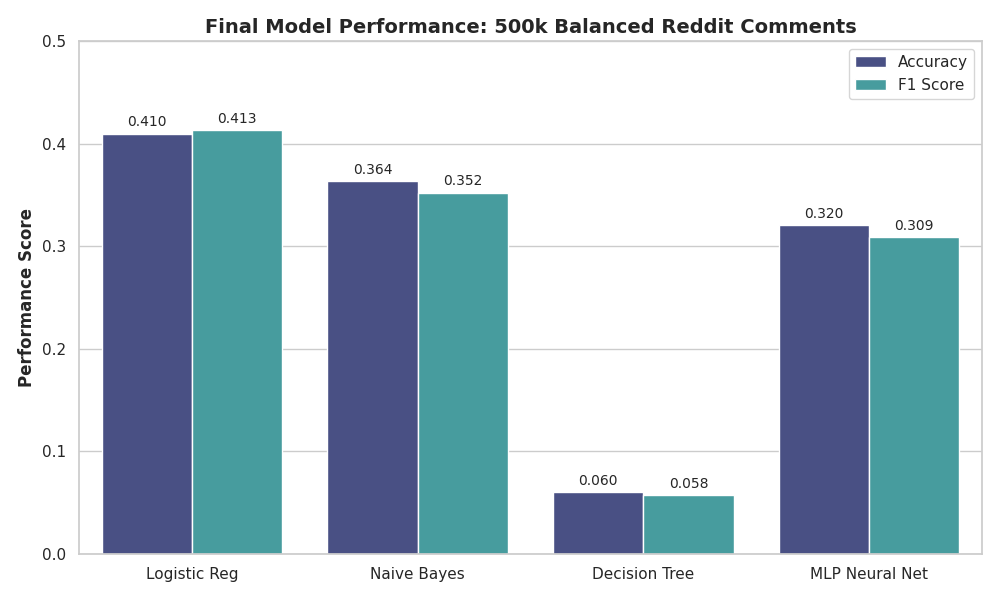

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", palette="deep")

data = {
    'Model': ['Logistic Reg', 'Naive Bayes', 'Decision Tree', 'MLP Neural Net'] * 2,
    'Metric': ['Accuracy']*4 + ['F1 Score']*4,
    'Score': [lr_acc, nb_acc, dt_acc, mlp_acc, 
              lr_f1, nb_f1, dt_f1, mlp_f1]
}
df_metrics = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_metrics, palette="mako")

ax.set_ylabel('Performance Score', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_title('Final Model Performance: 500k Balanced Reddit Comments', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.5) 

# Add exact numbers to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
%matplot plt

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

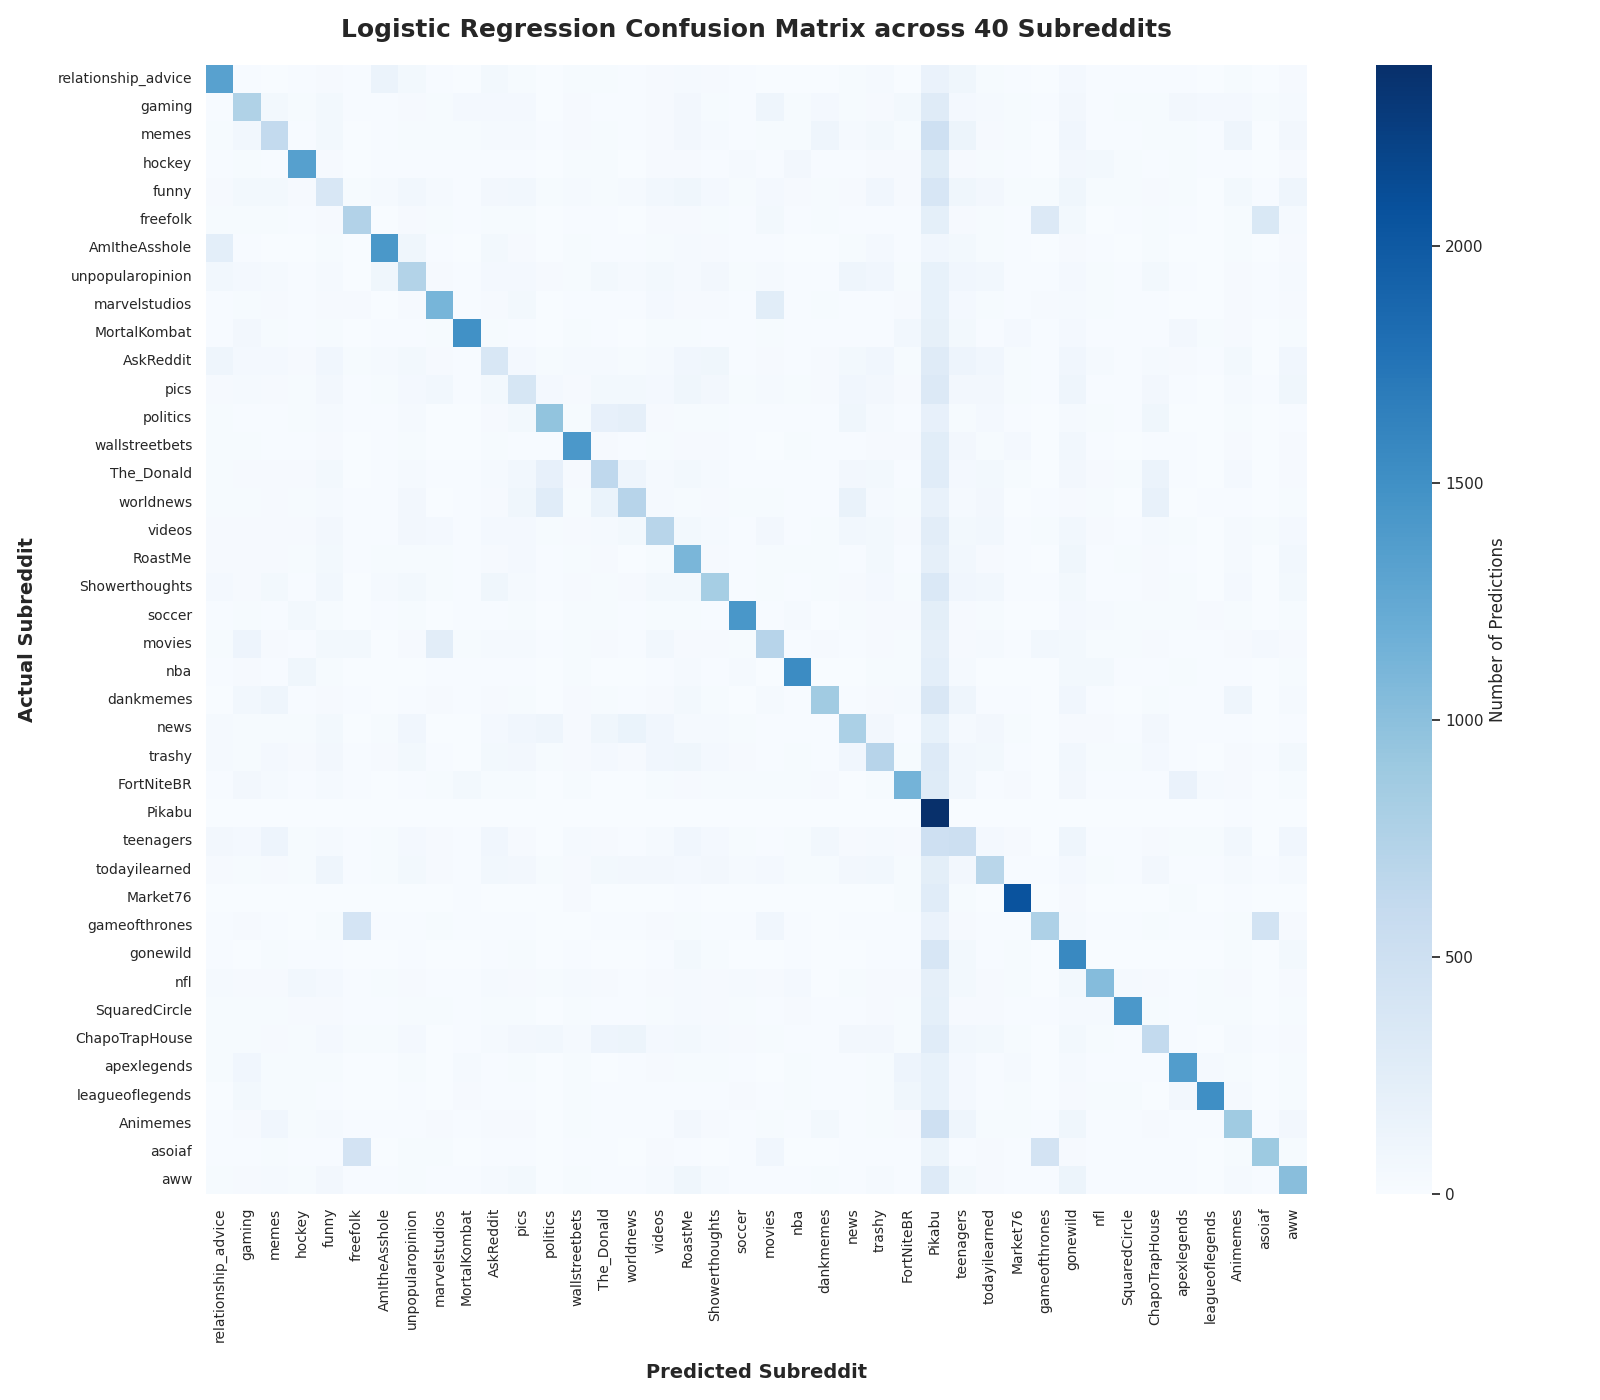

In [6]:
from sklearn.metrics import confusion_matrix

# Pull predictions from the winning model
preds_spark = lr_model.transform(test_data).select("label", "prediction")
preds_pd = preds_spark.toPandas()

# Extract labels and build the matrix
subreddit_labels = pre_model.stages[0].labels 
cm = confusion_matrix(preds_pd["label"], preds_pd["prediction"])

plt.figure(figsize=(16, 14))

sns.heatmap(cm, annot=False, cmap="Blues", 
            xticklabels=subreddit_labels, 
            yticklabels=subreddit_labels,
            cbar_kws={'label': 'Number of Predictions'})

plt.title("Logistic Regression Confusion Matrix across 40 Subreddits", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Predicted Subreddit", fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel("Actual Subreddit", fontsize=14, fontweight='bold', labelpad=15)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
from sklearn.metrics import confusion_matrix

print("Fetching predictions for the Confusion Matrix...")

# Pull predictions from the winning model
preds_spark = lr_model.transform(test_data).select("label", "prediction")
preds_pd = preds_spark.toPandas()

# Extract labels and build the matrix
subreddit_labels = pre_model.stages[0].labels 
cm = confusion_matrix(preds_pd["label"], preds_pd["prediction"])

plt.figure(figsize=(16, 14))

sns.heatmap(cm, annot=False, cmap="Blues", 
            xticklabels=subreddit_labels, 
            yticklabels=subreddit_labels,
            cbar_kws={'label': 'Number of Predictions'})

plt.title("Logistic Regression Confusion Matrix across 40 Subreddits", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Predicted Subreddit", fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel("Actual Subreddit", fontsize=14, fontweight='bold', labelpad=15)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
%matplot plt

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

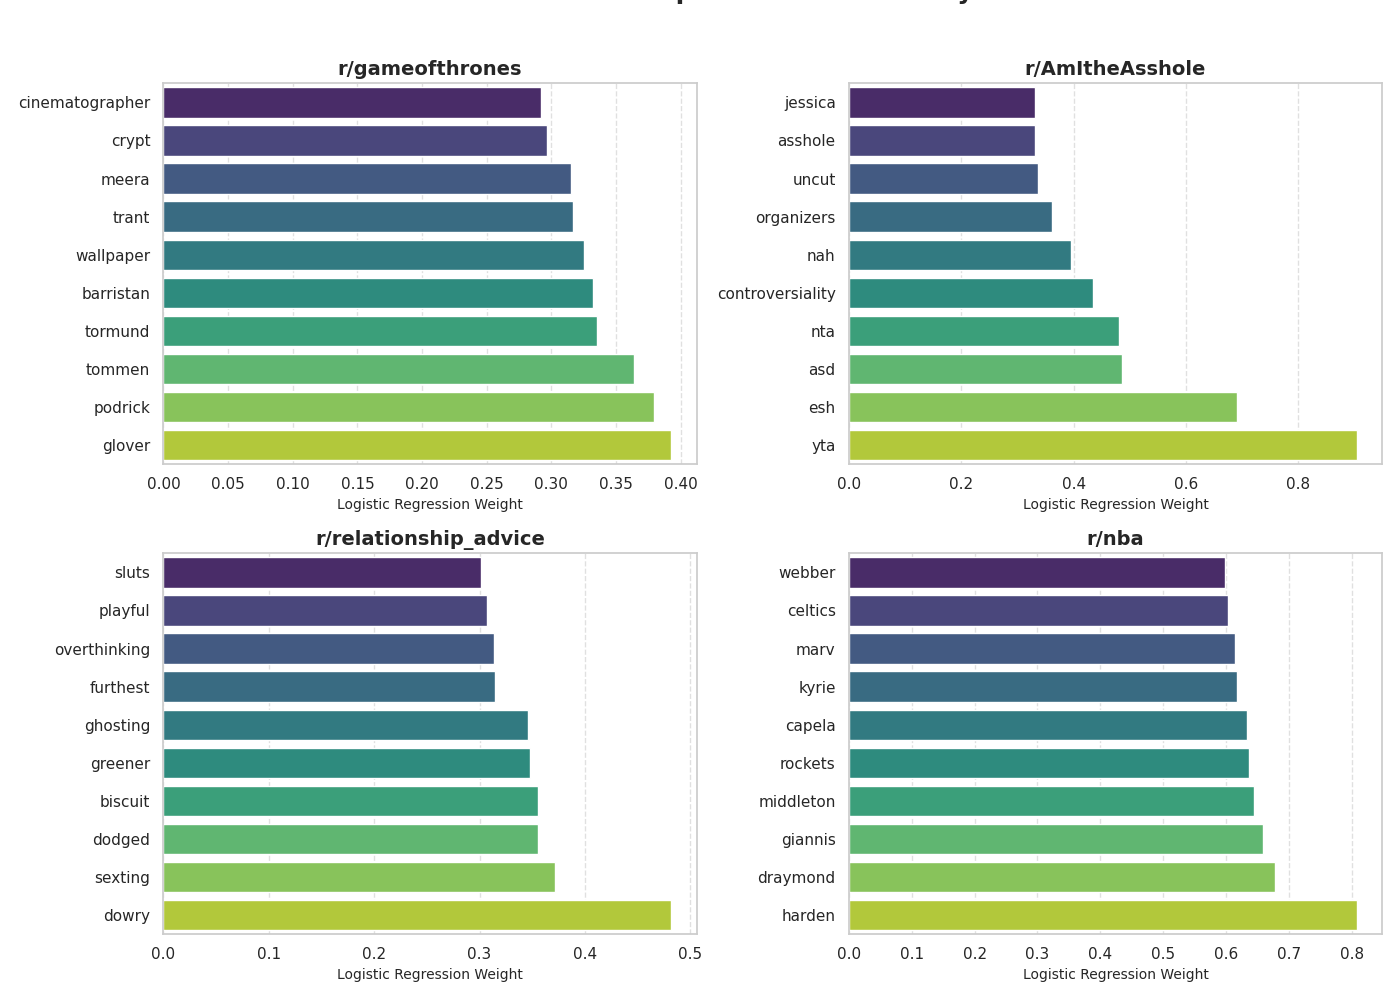

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

target_subreddits = ['gameofthrones', 'AmItheAsshole', 'relationship_advice', 'nba']

# Get the vocabulary dictionary from the preprocessing stage
vocab = pre_model.stages[3].vocabulary

# ADDITION: Create a master list of all feature names (vocab + the 2 numeric columns)
# This ensures the index lookup matches the 15,002 features in the model
all_feature_names = vocab + ['comment_score', 'controversiality']

# Set up a 2x2 grid for our charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Loop through our chosen subreddits and plot them
for idx, sub_name in enumerate(target_subreddits):
    if sub_name in subreddit_labels:
        # Find the internal ID number for this specific subreddit
        class_index = subreddit_labels.index(sub_name)
        
        # Grab the exact mathematical weights for this subreddit
        class_coefs = lr_model.coefficientMatrix.toArray()[class_index]
        
        # Find the indices of the top 10 highest weights
        top_indices = np.argsort(class_coefs)[-10:]
        
        # FIX: Use 'all_feature_names' instead of just 'vocab'
        top_words = [all_feature_names[i] for i in top_indices]
        top_weights = [class_coefs[i] for i in top_indices]
        
        # Draw the bar chart in the current grid slot
        sns.barplot(x=top_weights, y=top_words, ax=axes[idx], palette='viridis')
        axes[idx].set_title(f'r/{sub_name}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Logistic Regression Weight', fontsize=10)
        axes[idx].set_ylabel('')
        
        axes[idx].grid(axis='x', linestyle='--', alpha=0.6)
    else:
        axes[idx].set_title(f'r/{sub_name} (Not Found in Labels)')

plt.suptitle('What the Model Learned: Top Predictor Words by Subreddit', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
%matplot plt